In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import scipy
import PIL
import requests
import seaborn as sns


In [12]:
# Load Excel file
df = pd.read_csv(r"C:\Users\werne\OneDrive\Desktop\ontario_university_graduate_survey_en.csv", usecols=[0, 1, 2, 3], nrows=21)

# Display the first rows
print(df.head())

#View basic info
print(df.info())
print(df.describe())

  Institution    2018    2019    2020
0      Algoma  85.10%  87.00%  85.50%
1       Brock  91.90%  94.30%  90.10%
2    Carleton  90.30%  89.80%  85.90%
3      Guelph  92.00%  92.00%  86.20%
4      Hearst  80.00%       x  91.70%
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Institution  21 non-null     object
 1   2018         21 non-null     object
 2   2019         21 non-null     object
 3   2020         21 non-null     object
dtypes: object(4)
memory usage: 800.0+ bytes
None
       Institution    2018    2019    2020
count           21      21      21      21
unique          21      20      20      20
top         Algoma  91.90%  92.00%  90.10%
freq             1       2       2       2


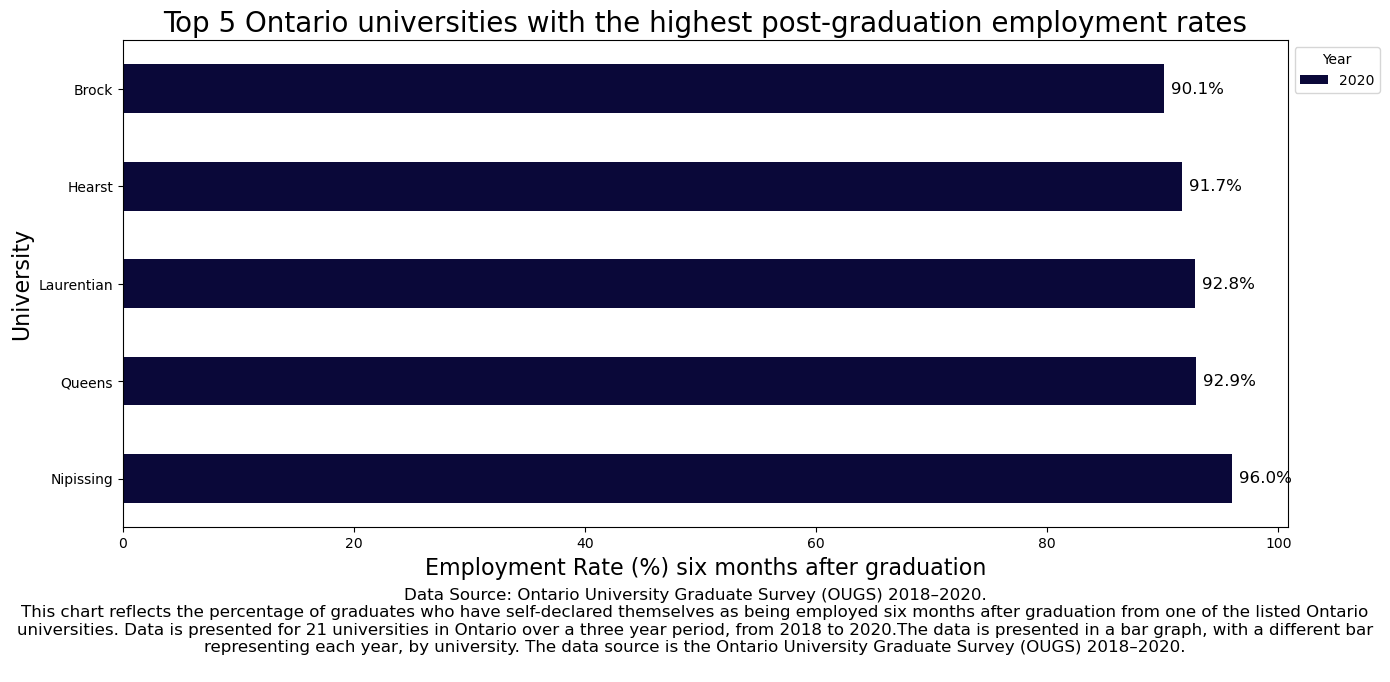

In [14]:
# Rename columns for easier access
df.columns = ["Institution", "2018", "2019", "2020"]

# Clean percentage strings and convert to float to ensure the data is plottable
for year in ["2018", "2019", "2020"]:
    df[year] = df[year].astype(str).str.replace('%', '', regex=False).str.replace('x', '', regex=False)
    df[year] = pd.to_numeric(df[year], errors='coerce')

# Set Institution as index - University names on x-axis
df.set_index("Institution", inplace=True)

# Sort and filter to get the Top 5 universities based on the most recent (2020) employment rates
# 1. Sort by the most recent year ("2020") in DESCENDING order (highest scores first).
# 2. Select the Top 5 rows using .head(5).
df = df.sort_values(by="2020", ascending=False).head(5)

# Filter for the most recent year
df_plot = df[['2020']]

# Define a single color for the bar
single_color = "#0a0839" 

# Plot the single column DataFrame
ax = df_plot.plot(kind='barh', figsize=(14, 6), color=single_color)

#Add data labels to each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=12, padding=5, label_type='edge') # Format to one decimal and add '%'

# Add titles and labels
plt.title("Top 5 Ontario universities with the highest post-graduation employment rates",
          ha='center', # Modify alignment of text
          color = 'black', # modify font color
          size = 20) # Modify font size)
plt.xlabel("Employment Rate (%) six months after graduation",
           ha='center', # Modify alignment of text
           color = 'black', # modify font color
           size = 16) # Modify font size))
plt.ylabel("University",
           ha='center', # Modify alignment of text
           color = 'black', # modify font color
           size = 16) # Modify font size)))

# Add legend
plt.legend(title="Year",
           loc ='upper left',
           bbox_to_anchor = (1, 1))
# Add description to assist with interpretation
plt.figtext(
    0.5, -0.12,
    "Data Source: Ontario University Graduate Survey (OUGS) 2018–2020.\n"
    "This chart reflects the percentage of graduates who have self-declared themselves as being employed six months after graduation from one of the listed Ontario universities. Data is presented for 21 universities in Ontario over a three year period, from 2018 to 2020.The data is presented in a bar graph, with a different bar representing each year, by university. The data source is the Ontario University Graduate Survey (OUGS) 2018–2020.\n",
    wrap=True,
    ha='center',
    color='black',
    fontsize=12
)
plt.tight_layout()
plt.show()

Visualization 2
Dataset taken from https://data.ontario.ca/dataset/ontario-university-graduate-survey/resource/34514ae3-927c-4510-a727-f18c4177f3d8 
See file "Assignment-3-Visualization2.png" 

    > What software did you use to create your data visualization?
    #  I used Python in Visual Studio Code. 
    > Who is your intended audience? 
    # Students who are interested in the level of employment of graduates from different universitieis in Ontario. 
    > What information or message are you trying to convey with your visualization? 
    # Which schools had the highest post-gradiation employment rates in 2020 (the most recent year of data) 
    > What aspects of design did you consider when making your visualization? How did you apply them? With what elements of your plots? 
    # Which graph would visally show the data the easiest given the length of name of the institutiions. 
    > How did you ensure that your data visualizations are reproducible? If the tool you used to make your data visualization is not reproducible, how will this impact your data visualization? 
    # I ensured it was reprodicble by using python so others can see the code used to run the data and produce the graphs. 
    > How did you ensure that your data visualization is accessible?  
    # I ensured the font size was large enough, the colours were easy to view for those with colour blindness, and added clear labels and a description. 
    > Who are the individuals and communities who might be impacted by your visualization?  
    # Employees of the univerities including the Dean, professors, department heads. 
    > How did you choose which features of your chosen dataset to include or exclude from your visualization? 
    # The data set was fairly straightforward. I opted to use the easiest data to understand which was the university name and percentage by year. 
    > What ‘underwater labour’ contributed to your final data visualization product?
    #Converting percentages, testing different chart type to see which would be the best visualization, testing different colours for each bar, adjusting labels, legends, descriptions, fixing syntax errors in my code. I tried to sort the data in ascending or descending order but had issued and could not correct it before the deadline. I will work on it in my spare time as I want to be able to correct this issue in order to use this type of visualization at work. 